# GW170817: Posterior plot comparison

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import bilby
import pandas as pd
import numpy as np
import seaborn as sns
from bilby.gw.result import CBCResult
import matplotlib.lines as mlines
from kde_contour import kdeplot_2d_clevels

size_axis_label = 13
size_tick_label = 11
size_legend_label = 12


### Waveforms: TaylorF2Ecck, TaylorF2Ecc 3PN

In [2]:
rng = np.random.default_rng(12345)

sns.set_theme(palette='colorblind', font_scale=1)

result1 = bilby.result.read_in_result("../result_files/TF2Ecck_3PN_bayeswave.hdf5").posterior
result2 = bilby.result.read_in_result("../result_files/TF2Ecc_3PN_bayeswave.hdf5").posterior
nsamples = min(len(result1), len(result2))

result_ecck = result1.sample(nsamples, random_state=rng)
result_ecck["templates"] = np.full(len(result_ecck), "Ecck 3PN")
result_ecck["chirp_mass"] = result_ecck["chirp_mass"]
result_ecck["eccentricity"] = result_ecck["eccentricity"]


result_ecc3PN = result2.sample(nsamples, random_state=rng)
result_ecc3PN["templates"] = np.full(len(result_ecc3PN), "Ecc 3PN")
result_ecc3PN["chirp_mass"] = result_ecc3PN["chirp_mass"]
result_ecc3PN["eccentricity"] = result_ecc3PN["eccentricity"]

result = pd.concat([result_ecck, result_ecc3PN],ignore_index=True)

03:26 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
03:26 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [3]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'backend': 'Agg',
    'savefig.dpi': 300,
    'grid.alpha': 0.5,
    'path.simplify': True,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label,
    "axes.labelsize": size_axis_label,
    "xtick.labelsize": size_tick_label,
    "ytick.labelsize": size_tick_label,
    "legend.fontsize": size_legend_label,
    'mathtext.fontset': 'custom',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'lines.markeredgewidth': 1,
    'legend.numpoints': 1,
    'legend.frameon': False,
    'legend.handletextpad': 0.3
})

vars = ['chirp_mass', 'mass_ratio', 'eccentricity']
waveforms = ['Ecck 3PN', 'Ecc 3PN']
palette = {'Ecck 3PN': 'C0', 'Ecc 3PN': 'C1'}

diag_fill_alpha = 0.15
g = sns.pairplot(
    result,
    vars=vars,
    hue='templates',
    palette=palette,
    corner=True,
    kind='scatter',
    plot_kws=dict(marker='.', alpha=0.0, s=5),
    diag_kind='kde',
    diag_kws={'alpha': diag_fill_alpha, 'linewidth': 0.8, 'bw_adjust': 1.0},
    height=1.5,
)

contour_levels = np.sort([0.864, 0.393])
for i, row_var in enumerate(vars):
    for j, col_var in enumerate(vars):
        if i > j:
            ax = g.axes[i, j]
            for waveform, color in palette.items():
                subset = result[result['templates'] == waveform]
                kdeplot_2d_clevels(
                    xs=subset[col_var],
                    ys=subset[row_var],
                    levels=contour_levels,
                    ax=ax,
                    color=color,
                    linewidths=0.8,
                    auto_bound=False,
                    bw_method=0.4,
                )

if g._legend is not None:
    g._legend.remove()
# 14s

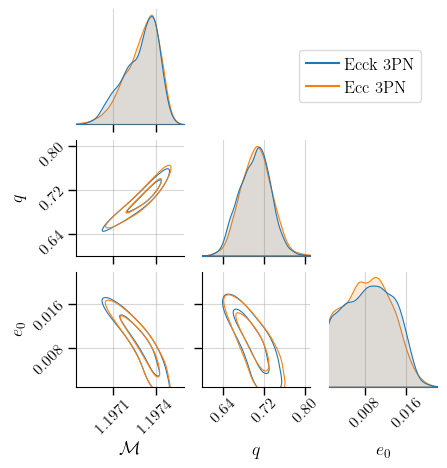

In [4]:
g.axes[2, 2].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 1].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='y', rotation=45, pad=1)
g.axes[1, 0].tick_params(axis='y', rotation=45, pad=1)
# set maximum number of ticks on each axis
g.axes[2, 2].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 1].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 0].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 0].yaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[1, 0].yaxis.set_major_locator(plt.MaxNLocator(3))

g.axes[2, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.4f' % x))
g.axes[2, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.2f' % x))
g.axes[2, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.2f' % x))      

for ax in g.axes.flat:
    if ax is not None:
        ax.tick_params(axis='both', which='both', labelsize=size_tick_label)

x_label_y = -0.48
g.axes[2,0].set_xlabel(r'$\mathcal{M}$', labelpad=0, fontsize=size_axis_label)
g.axes[1,0].set_ylabel(r'$q$', labelpad=8, fontsize=size_axis_label)
g.axes[2,1].set_xlabel(r'$q$', labelpad=0, fontsize=size_axis_label)
g.axes[2,0].set_ylabel(r'$e_0$', labelpad=4, fontsize=size_axis_label)
g.axes[2,2].set_xlabel(r'$e_0$', labelpad=0, fontsize=size_axis_label)
for ax in (g.axes[2, 0], g.axes[2, 1], g.axes[2, 2]):
    ax.xaxis.set_label_coords(0.5, x_label_y)

min_mc = 1.19683
max_mc = 1.19760
min_q = 0.60
max_q = 0.81
min_e0 = 0.001
max_e0 = 0.022
g.axes[2,0].set_xlim(min_mc, max_mc)
g.axes[2,0].set_ylim(min_e0, max_e0)
g.axes[2,2].set_xlim(min_e0, max_e0)
g.axes[2,1].set_xlim(min_q, max_q)
g.axes[1,0].set_ylim(min_q, max_q)

# add grid
for i in range(3):
    for j in range(3):
        if g.axes[i, j] is not None:
            g.axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN')
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3PN')
handles = [blue_line, orange_line]
labels = [h.get_label() for h in handles] 
legend = g.fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.75, .0), ncol=1, frameon=True, fontsize=size_legend_label, edgecolor='lightgray') # Adjust loc and ncol as needed
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)

plt.savefig("injection_recovery_Ecck_vs_TF2_e0_0p05_GW190425.pdf", bbox_inches="tight", dpi=300)
g.savefig("GW170817a.pdf", bbox_inches="tight", dpi=300)
plt.show()

### Waveforms: TaylorF2Ecck, TaylorF2Ecc 3PN, TaylorF2Ecc 3.5PN

In [5]:
rng = np.random.default_rng(12345)

sns.set_theme(palette='colorblind', font_scale=1)

result4 = bilby.result.read_in_result("../result_files/TF2Ecc_3p5PN_bayeswave.hdf5").posterior
result_ecc3p5nospin = result4.sample(nsamples, random_state=rng)
result_ecc3p5nospin["templates"] = np.full(len(result_ecc3p5nospin), "Ecc 3.5PN")
result_ecc3p5nospin["chirp_mass"] = result_ecc3p5nospin["chirp_mass"]
result_ecc3p5nospin["eccentricity"] = result_ecc3p5nospin["eccentricity"]

result = pd.concat([result_ecck, result_ecc3p5nospin],ignore_index=True)

03:26 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [6]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'backend': 'Agg',
    'savefig.dpi': 300,
    'grid.alpha': 0.5,
    'path.simplify': True,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label,
    "axes.labelsize": size_axis_label,
    "xtick.labelsize": size_tick_label,
    "ytick.labelsize": size_tick_label,
    "legend.fontsize": size_legend_label,
    'mathtext.fontset': 'custom',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'lines.markeredgewidth': 1,
    'legend.numpoints': 1,
    'legend.frameon': False,
    'legend.handletextpad': 0.3
})

vars = ['chirp_mass', 'mass_ratio', 'eccentricity']
waveforms = ['Ecck 3PN', 'Ecc 3.5PN']
palette = {'Ecck 3PN': 'C0', 'Ecc 3.5PN': 'C3'}

diag_fill_alpha = 0.15
g = sns.pairplot(
    result,
    vars=vars,
    hue='templates',
    palette=palette,
    corner=True,
    kind='scatter',
    plot_kws=dict(marker='.', alpha=0.0, s=5),
    diag_kind='kde',
    diag_kws={'alpha': diag_fill_alpha, 'linewidth': 0.8, 'bw_adjust': 1.0},
    height=1.5,
)

contour_levels = np.sort([0.864, 0.393])
for i, row_var in enumerate(vars):
    for j, col_var in enumerate(vars):
        if i > j:
            ax = g.axes[i, j]
            for waveform, color in palette.items():
                subset = result[result['templates'] == waveform]
                kdeplot_2d_clevels(
                    xs=subset[col_var],
                    ys=subset[row_var],
                    levels=contour_levels,
                    ax=ax,
                    color=color,
                    linewidths=0.8,
                    auto_bound=False,
                    bw_method=0.4,
                )

if g._legend is not None:
    g._legend.remove()
# 32s

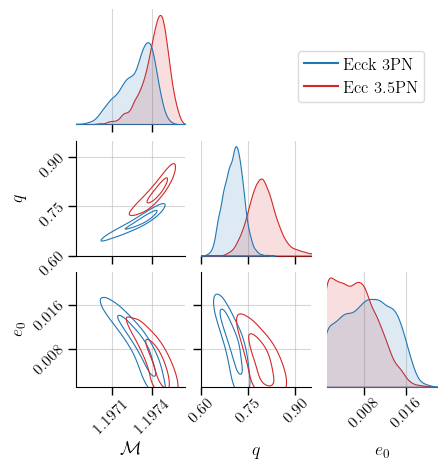

In [7]:
g.axes[2, 2].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 1].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='y', rotation=45, pad=1)
g.axes[1, 0].tick_params(axis='y', rotation=45, pad=1)

g.axes[2, 2].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 1].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 0].xaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[2, 0].yaxis.set_major_locator(plt.MaxNLocator(3))
g.axes[1, 0].yaxis.set_major_locator(plt.MaxNLocator(3))

g.axes[2, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.4f' % x))
g.axes[2, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.2f' % x))
g.axes[2, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.2f' % x))      

for ax in g.axes.flat:
    if ax is not None:
        ax.tick_params(axis='both', which='both', labelsize=size_tick_label)

x_label_y = -0.48
g.axes[2,0].set_xlabel(r'$\mathcal{M}$', labelpad=0, fontsize=size_axis_label)
g.axes[1,0].set_ylabel(r'$q$', labelpad=8, fontsize=size_axis_label)
g.axes[2,1].set_xlabel(r'$q$', labelpad=0, fontsize=size_axis_label)
g.axes[2,0].set_ylabel(r'$e_0$', labelpad=4, fontsize=size_axis_label)
g.axes[2,2].set_xlabel(r'$e_0$', labelpad=0, fontsize=size_axis_label)
for ax in (g.axes[2, 0], g.axes[2, 1], g.axes[2, 2]):
    ax.xaxis.set_label_coords(0.5, x_label_y)

min_mc = 1.19683
max_mc = 1.19765
min_q = 0.60
max_q = 0.95
min_e0 = 0.001
max_e0 = 0.022
g.axes[2,0].set_xlim(min_mc, max_mc)
g.axes[2,0].set_ylim(min_e0, max_e0)
g.axes[2,2].set_xlim(min_e0, max_e0)
g.axes[2,1].set_xlim(min_q, max_q)
g.axes[1,0].set_ylim(min_q, max_q)

# add grid
for i in range(3):
    for j in range(3):
        if g.axes[i, j] is not None:
            g.axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN')
green_line = mlines.Line2D([], [], color='C3', label='Ecc 3.5PN')
handles = [blue_line, green_line]
labels = [h.get_label() for h in handles] 
legend = g.fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.75, .0), ncol=1, frameon=True, fontsize=size_legend_label, edgecolor='lightgray') # Adjust loc and ncol as needed
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
g.savefig("GW170817b.pdf", bbox_inches="tight", dpi=300)
plt.show()